#Data Loading

In [ ]:
import pandas as pd
import io
Incarcerated= pd.read_csv('Incarcerated.csv')

In [ ]:
Incarcerated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37573 entries, 0 to 37572
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INMATEID            37573 non-null  int64  
 1   ADMITTED_DT         37573 non-null  object 
 2   DISCHARGED_DT       0 non-null      float64
 3   CUSTODY_LEVEL       36513 non-null  object 
 4   BRADH               37573 non-null  object 
 5   RACE                37473 non-null  object 
 6   GENDER              37476 non-null  object 
 7   AGE                 37533 non-null  float64
 8   INMATE_STATUS_CODE  37573 non-null  object 
 9   SEALED              37573 non-null  object 
 10  SRG_FLG             37573 non-null  object 
 11  TOP_CHARGE          34536 non-null  object 
 12  INFRACTION          37573 non-null  object 
 13  YEAR                37573 non-null  int64  
dtypes: float64(2), int64(2), object(10)
memory usage: 4.0+ MB


In [ ]:
Incarcerated.value_counts('TOP_CHARGE')

,count
TOP_CHARGE,
125.25,3921
110-125.25,2698
160.15,2347
265.03,2095
120.05,1926
...,...
110-125.25H,1
110-130.35H,1
VTL 666.66,1


In [ ]:
# Check if any string in ADMITTED_DT contains '2026'
has_2026 = Incarcerated['ADMITTED_DT'].str.contains('2026').any()

print(f"Are there 2026 admissions in ADMITTED_DT? {has_2026}")

# If you want to see the first few rows that actually have 2026:
if has_2026:
    display(Incarcerated[Incarcerated['ADMITTED_DT'].str.contains('2026')])


Are there 2026 admissions in ADMITTED_DT? True


,INMATEID,ADMITTED_DT,DISCHARGED_DT,CUSTODY_LEVEL,BRADH,RACE,GENDER,AGE,INMATE_STATUS_CODE,SEALED,SRG_FLG,TOP_CHARGE,INFRACTION,YEAR
74,20226626,01/24/2026 12:11:56 PM,NaN,MED,N,B,M,57.0,DEP,N,N,VOP,N,26
87,20228751,01/20/2026 10:20:57 PM,NaN,MIN,Y,B,M,40.0,DE,N,N,140.25,N,26
92,20226062,01/29/2026 03:22:11 PM,NaN,MIN,N,O,M,52.0,DNS,N,N,NaN,N,26
128,20115174,01/27/2026 04:40:16 PM,NaN,MIN,Y,NaN,NaN,32.0,CS,N,N,NaN,N,26
153,20248257,01/13/2026 12:15:45 AM,NaN,MIN,N,O,M,30.0,DE,N,N,160.10,N,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37526,20248706,02/07/2026 06:29:00 PM,NaN,NaN,N,W,F,44.0,DE,N,N,120.00,N,26
37528,10002402,01/09/2026 04:02:28 PM,NaN,MED,N,B,M,44.0,DE,N,N,265.01,N,26
37566,20248716,02/08/2026 10:39:20 PM,NaN,MED,N,B,M,21.0,DE,N,N,110-125.25,N,26
37567,20248443,01/22/2026 05:41:27 PM,NaN,MIN,N,B,M,31.0,DE,N,N,110-125.25,N,26


In [ ]:
# Look at rows where YEAR is 26 but ADMITTED_DT is NOT 2026
mismatch = Incarcerated[(Incarcerated['YEAR'] == 26) & (~Incarcerated['ADMITTED_DT'].str.contains('2026'))]
mismatch[['ADMITTED_DT', 'YEAR', 'INMATE_STATUS_CODE']].head(10)

,ADMITTED_DT,YEAR,INMATE_STATUS_CODE
3,03/22/2025 12:33:00 AM,26,DE
15,04/26/2024 02:48:20 PM,26,DE
19,08/19/2024 04:56:51 PM,26,DE
26,06/05/2025 07:51:50 PM,26,DE
34,11/06/2025 02:26:07 PM,26,DE
37,12/19/2025 11:59:23 PM,26,DE
41,11/23/2025 08:30:00 PM,26,DE
42,09/28/2025 01:34:18 AM,26,CS
46,08/06/2025 07:57:04 AM,26,DE
53,12/16/2025 11:13:58 PM,26,DE


In [ ]:
Incarcerated.isnull().sum()

,0
INMATEID,0
ADMITTED_DT,0
DISCHARGED_DT,37573
CUSTODY_LEVEL,1060
BRADH,0
RACE,100
GENDER,97
AGE,40
INMATE_STATUS_CODE,0
SEALED,0


In [ ]:
Incarcerated.head()

,INMATEID,ADMITTED_DT,DISCHARGED_DT,CUSTODY_LEVEL,BRADH,RACE,GENDER,AGE,INMATE_STATUS_CODE,SEALED,SRG_FLG,TOP_CHARGE,INFRACTION,YEAR
0,10011382,05/16/2017 09:14:38 PM,NaN,MED,N,B,M,60.0,DEP,N,N,205.30,N,17
1,20208589,05/05/2022 05:22:41 PM,NaN,MIN,Y,B,M,26.0,DE,N,N,130.52,N,22
2,20158122,10/17/2015 12:15:33 AM,NaN,MAX,N,B,F,26.0,DE,N,N,125.25,Y,21
3,20242322,03/22/2025 12:33:00 AM,NaN,MED,Y,B,M,23.0,DE,N,N,150.15,N,26
4,19968,06/16/2017 04:45:26 AM,NaN,MED,N,O,M,58.0,DPV,N,N,NaN,N,17


In [ ]:
from sklearn.model_selection import train_test_split

Incarcerated_training, Incarcerated_test = train_test_split(Incarcerated,
                                  test_size=0.15, random_state=42)

print(f"Training set: {len(Incarcerated_training)} rows")
print(f"Testing set: {len(Incarcerated_test)} rows")


NameError: name 'Incarcerated' is not defined

#Data Visualization

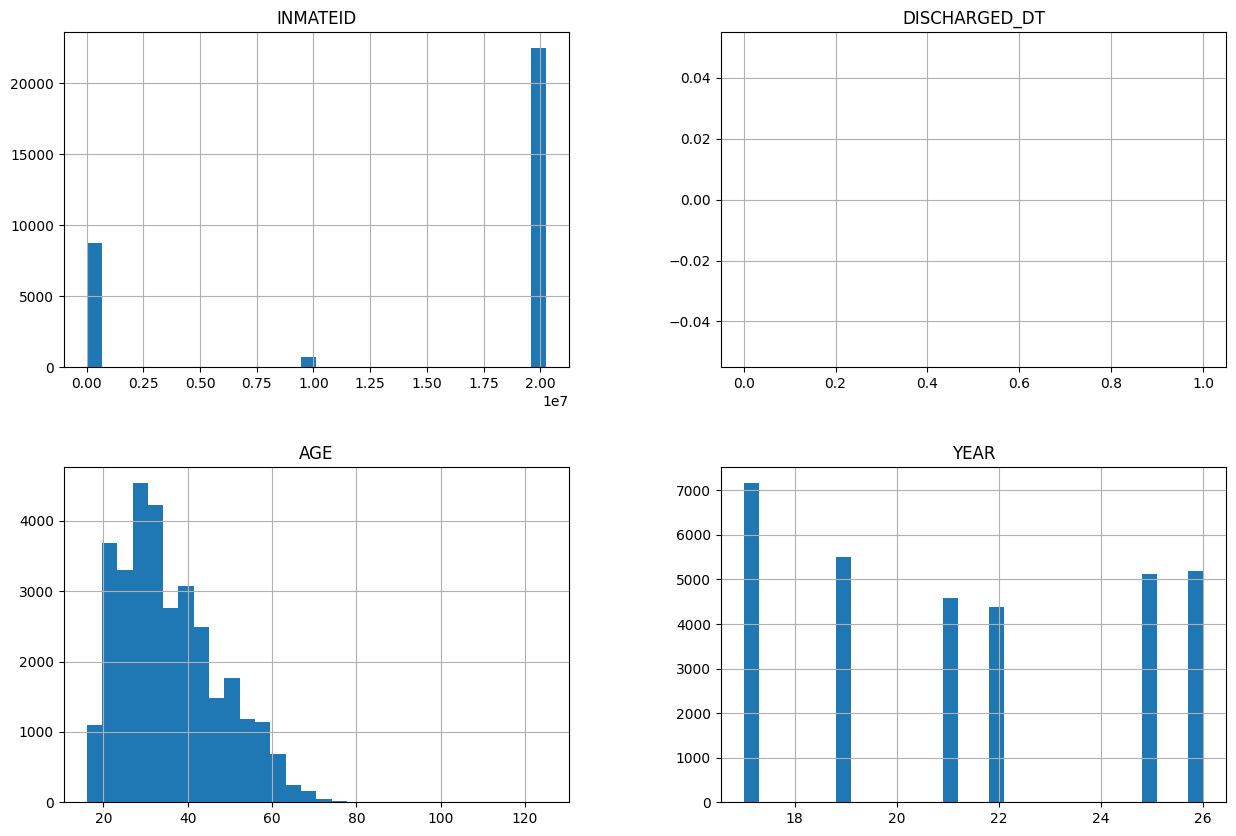

In [ ]:
import matplotlib.pyplot as plt

Incarcerated_training.hist(bins=30, figsize=(15, 10))
plt.show()

#Feature engineering

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

#Defines the specific order
level_order= ['MIN','MED','MAX']

#initialize encoder with the order
ordinal_encoder = OrdinalEncoder(categories=[level_order],
                    handle_unknown='use_encoded_value', unknown_value=-1)

#create a new column to put the encoded data
Incarcerated_training['CUSTODY_LEVEL_NUM']= ordinal_encoder.fit_transform(Incarcerated_training[['CUSTODY_LEVEL']])

#check values
print(Incarcerated_training[['CUSTODY_LEVEL', 'CUSTODY_LEVEL_NUM']].head())



      CUSTODY_LEVEL  CUSTODY_LEVEL_NUM
36957           MIN                0.0
4817            MAX                2.0
7779            MAX                2.0
5975            MED                1.0
13130           MED                1.0


In [ ]:
#drop old colummn
Incarcerated_training = Incarcerated_training.drop('CUSTODY_LEVEL', axis=1)

print(Incarcerated_training.columns)

Index(['INMATEID', 'ADMITTED_DT', 'DISCHARGED_DT', 'BRADH', 'RACE', 'GENDER',
       'AGE', 'INMATE_STATUS_CODE', 'SEALED', 'SRG_FLG', 'TOP_CHARGE',
       'INFRACTION', 'YEAR'],
      dtype='object')


In [ ]:
binary_columns = ['BRADH', 'INFRACTION', 'SRG_FLG']

#replaces Y with 1 and N with 0
for col in binary_columns:
    Incarcerated_training[binary_columns] = Incarcerated_training[binary_columns].replace({'Y': 1, 'N': 0})

pd.set_option('future.no_silent_downcasting', True)
Incarcerated_training[binary_columns]


,BRADH,INFRACTION,SRG_FLG
36957,1,1,0
4817,1,1,1
7779,1,1,1
5975,0,1,0
13130,1,1,0
...,...,...,...
16850,1,0,0
6265,0,0,0
11284,0,1,1
860,0,0,0


In [ ]:
binary_cols = ['BRADH', 'INFRACTION', 'SRG_FLG']
Incarcerated_training[binary_cols] = Incarcerated_training[binary_cols].astype(int)

In [ ]:
Incarcerated_training['BRADH'].value_counts()

,count
BRADH,
0,16120
1,15817


In [ ]:
Incarcerated_training.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31937 entries, 36957 to 15795
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INMATEID            31937 non-null  int64  
 1   ADMITTED_DT         31937 non-null  object 
 2   DISCHARGED_DT       0 non-null      float64
 3   CUSTODY_LEVEL       31039 non-null  object 
 4   BRADH               31937 non-null  int64  
 5   RACE                31851 non-null  object 
 6   GENDER              31854 non-null  object 
 7   AGE                 31901 non-null  float64
 8   INMATE_STATUS_CODE  31937 non-null  object 
 9   SEALED              31937 non-null  object 
 10  SRG_FLG             31937 non-null  int64  
 11  TOP_CHARGE          29353 non-null  object 
 12  INFRACTION          31937 non-null  int64  
 13  YEAR                31937 non-null  int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 4.7+ MB


In [ ]:
# group Nans's into U because U for race propably stands for unknown
Incarcerated_training['RACE'] = Incarcerated_training['RACE'].fillna('U')

# for GENDER create a new category called unknown
Incarcerated_training['GENDER'] = Incarcerated_training['GENDER'].fillna('UNKNOWN')

print(Incarcerated_training[['RACE', 'GENDER']].isna().sum())

RACE      0
GENDER    0
dtype: int64


In [ ]:
#Year changed to categorical to help with grouping as year is not based on when an
#was admited
Incarcerated_training['YEAR'] = Incarcerated_training['YEAR'].astype(str)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# multiple colums
nominal_cols = ['RACE', 'GENDER', 'INMATE_STATUS_CODE', 'YEAR']

# drop='first' helps avoid the dummy variable trap by removing redundant info
oh_encoder = OneHotEncoder(drop='first', sparse_output=False)

#fit and transform
encoded_array = oh_encoder.fit_transform(Incarcerated_training[nominal_cols])

# Convert back to a DataFrame with clear column names
encoded_df = pd.DataFrame(
    encoded_array,
    columns=oh_encoder.get_feature_names_out(nominal_cols),
    index=Incarcerated_training.index
)

# Combine with your training set and drop the old text columns
Incarcerated_training_final = pd.concat([Incarcerated_training.drop(nominal_cols, axis=1), encoded_df], axis=1)

# display the result to see your new binary columns
print(Incarcerated_training_final.columns)


Index(['INMATEID', 'ADMITTED_DT', 'DISCHARGED_DT', 'BRADH', 'AGE', 'SEALED',
       'SRG_FLG', 'TOP_CHARGE', 'INFRACTION', 'CUSTODY_LEVEL_NUM', 'RACE_B',
       'RACE_I', 'RACE_O', 'RACE_U', 'RACE_W', 'GENDER_M', 'GENDER_UNKNOWN',
       'INMATE_STATUS_CODE_CSP', 'INMATE_STATUS_CODE_DE',
       'INMATE_STATUS_CODE_DEP', 'INMATE_STATUS_CODE_DNS',
       'INMATE_STATUS_CODE_DPV', 'INMATE_STATUS_CODE_SCO',
       'INMATE_STATUS_CODE_SSR', 'YEAR_19', 'YEAR_21', 'YEAR_22', 'YEAR_25',
       'YEAR_26'],
      dtype='object')


In [ ]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy='median')
Incarcerated_training['AGE'] = age_imputer.fit_transform(Incarcerated_training[['AGE']])

print(f"Missing values in AGE: {Incarcerated_training['AGE'].isna().sum()}")

Missing values in AGE: 0


In [ ]:
#dropping sealed
cols_to_drop = ['SEALED', 'DISCHARGED_DT']
Incarcerated_training = Incarcerated_training.drop(columns=cols_to_drop)

print("SEALED" in Incarcerated_training.columns)

False


In [ ]:
print("DISCHARGED_DT" in Incarcerated_training.columns)

False


In [ ]:
#handels top charges missing values
Incarcerated_training['TOP_CHARGE'] = Incarcerated_training['TOP_CHARGE'].fillna('UNKNOWN')

#Model A Training

In [ ]:
Incarcerated_training.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31937 entries, 36957 to 15795
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INMATEID            31937 non-null  int64  
 1   ADMITTED_DT         31937 non-null  object 
 2   DISCHARGED_DT       0 non-null      float64
 3   CUSTODY_LEVEL       31039 non-null  object 
 4   BRADH               31937 non-null  int64  
 5   RACE                31851 non-null  object 
 6   GENDER              31854 non-null  object 
 7   AGE                 31901 non-null  float64
 8   INMATE_STATUS_CODE  31937 non-null  object 
 9   SEALED              31937 non-null  object 
 10  SRG_FLG             31937 non-null  int64  
 11  TOP_CHARGE          29353 non-null  object 
 12  INFRACTION          31937 non-null  int64  
 13  YEAR                31937 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 4.7+ MB


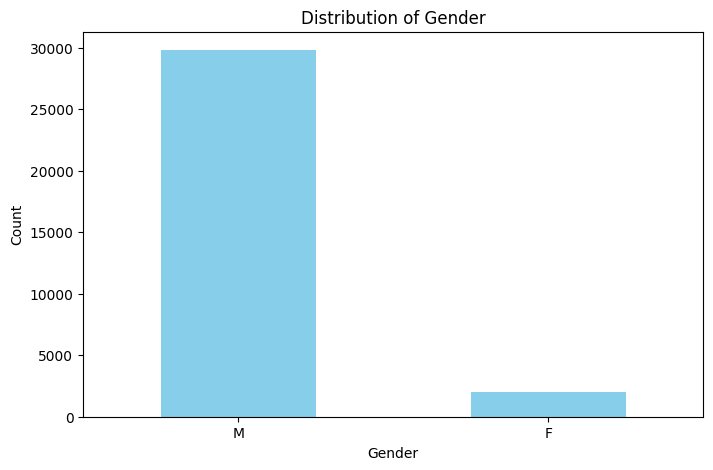

In [ ]:
plt.figure(figsize=(8, 5))
Incarcerated_training['GENDER'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#Pipeline A

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

drop_cols = ['SEALED','DISCHARGED_DT','INMATEID','TOP_CHARGE','ADMITTED_DT']
X = Incarcerated_training.drop(columns=['GENDER']).copy()
X = X.drop(columns=drop_cols, errors='ignore')

y = Incarcerated_training['GENDER'].astype(str)

numeric_features = ['AGE']
categorical_features = ['RACE','INMATE_STATUS_CODE','YEAR','BRADH', 'SRG_FLG','INFRACTION']
ordinal_features = ['CUSTODY_LEVEL']

#make pipelines
num_pipeline= make_pipeline(SimpleImputer(strategy= 'median'), StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy='constant', fill_value='unknown'),
                             OneHotEncoder(sparse_output=False))
ord_pipeline = make_pipeline( OrdinalEncoder(categories=[['MIN','MED','MAX']],
                                             handle_unknown='use_encoded_value', unknown_value=-1))

preprocessing = ColumnTransformer([
    ('num',num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
    ('ord',ord_pipeline, ordinal_features),

])

full_pipelineA = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit pipeline
full_pipelineA.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['RACE', 'INMATE_STATUS_CODE',
                                                   'YEAR', 'BRADH', 'SRG_FLG',
                                                   'INFRACTION']),
                                                 ('ord',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['MIN',
                                                                                               'MED',
                                                                                               'MAX']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['CUSTODY_LEVEL'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

#Performance Metrics

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(full_pipelineA, X,y, cv=4, scoring ='accuracy')

array([0.92022542, 0.91846192, 0.91357715, 0.91921343])

In [ ]:
cross_val_score(full_pipelineA, X,y, cv=4, scoring ='f1_macro')

array([0.66976023, 0.68967533, 0.67605242, 0.69332988])

In [ ]:
processed_sample = full_pipelineA.named_steps['preprocessor'].transform(X.head(10))

feature_names = full_pipelineA.named_steps['preprocessor'].get_feature_names_out()
result_df = pd.DataFrame(processed_sample, columns=feature_names)
result_df.head(10)

,num__AGE,cat__RACE_A,cat__RACE_B,cat__RACE_I,cat__RACE_O,cat__RACE_U,cat__RACE_W,cat__RACE_unknown,cat__INMATE_STATUS_CODE_CS,cat__INMATE_STATUS_CODE_CSP,...,cat__YEAR_22,cat__YEAR_25,cat__YEAR_26,cat__BRADH_N,cat__BRADH_Y,cat__SRG_FLG_N,cat__SRG_FLG_Y,cat__INFRACTION_N,cat__INFRACTION_Y,ord__CUSTODY_LEVEL
0,0.703585,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,0.278187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0
2,-1.253247,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0
3,-0.912929,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.193107,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
5,-0.572610,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
6,1.639461,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
7,1.979780,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
8,-0.742769,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0
9,-0.657690,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0


#Model B Training

In [ ]:
Incarcerated_training['SRG_FLG'].describe()

,SRG_FLG
count,31937
unique,2
top,N
freq,26185


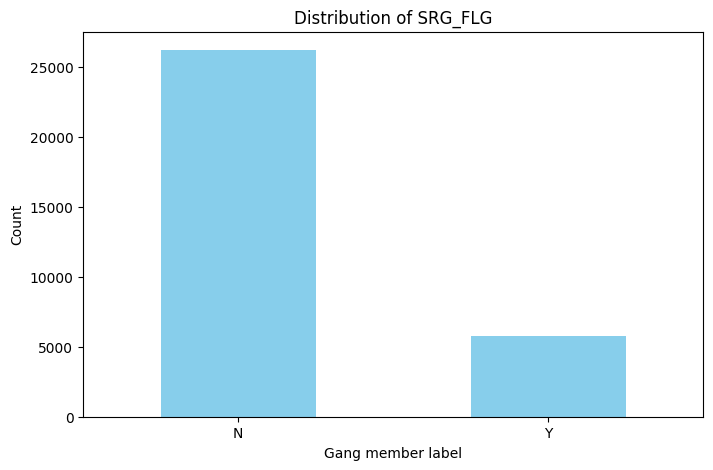

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
Incarcerated_training['SRG_FLG'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of SRG_FLG')
plt.xlabel('Gang member label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#pipeline B

In [ ]:


drop_cols = ['SEALED','DISCHARGED_DT','INMATEID','TOP_CHARGE','ADMITTED_DT']
X = Incarcerated_training.drop(columns=['SRG_FLG']).copy()
X = X.drop(columns=drop_cols, errors='ignore')

y = Incarcerated_training['SRG_FLG'].astype(str)


numeric_features = ['AGE']
categorical_features = ['RACE','INMATE_STATUS_CODE','YEAR','BRADH', 'GENDER','INFRACTION']
ordinal_features = ['CUSTODY_LEVEL']

#make pipelines
num_pipeline= make_pipeline(SimpleImputer(strategy= 'median'), StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy='constant', fill_value='unknown'),
                             OneHotEncoder(sparse_output=False))
ord_pipeline = make_pipeline( OrdinalEncoder(categories=[['MIN','MED','MAX']],
                                             handle_unknown='use_encoded_value', unknown_value=-1))



preprocessing = ColumnTransformer([
    ('num',num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
    ('ord',ord_pipeline, ordinal_features),

])

full_pipelineB = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit pipeline
full_pipelineB.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['RACE', 'INMATE_STATUS_CODE',
                                                   'YEAR', 'BRADH', 'GENDER',
                                                   'INFRACTION']),
                                                 ('ord',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['MIN',
                                                                                               'MED',
                                                                                               'MAX']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['CUSTODY_LEVEL'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

#Performance metrics

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(full_pipelineB, X,y, cv=4, scoring ='accuracy')

array([0.83443957, 0.82915832, 0.8259018 , 0.83366733])

In [ ]:
cross_val_score(full_pipelineB, X,y, cv=4, scoring ='f1_macro')

array([0.70692721, 0.69848943, 0.69039356, 0.70102043])

In [ ]:
processed_sample = full_pipelineB.named_steps['preprocessor'].transform(X.head(10))

feature_names = full_pipelineB.named_steps['preprocessor'].get_feature_names_out()
result_df = pd.DataFrame(processed_sample, columns=feature_names)
result_df.head(10)

,num__AGE,cat__RACE_A,cat__RACE_B,cat__RACE_I,cat__RACE_O,cat__RACE_U,cat__RACE_W,cat__RACE_unknown,cat__INMATE_STATUS_CODE_CS,cat__INMATE_STATUS_CODE_CSP,...,cat__YEAR_25,cat__YEAR_26,cat__BRADH_N,cat__BRADH_Y,cat__GENDER_F,cat__GENDER_M,cat__GENDER_unknown,cat__INFRACTION_N,cat__INFRACTION_Y,ord__CUSTODY_LEVEL
0,0.703585,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.278187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
2,-1.253247,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0
3,-0.912929,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.193107,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
5,-0.572610,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
6,1.639461,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
7,1.979780,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
8,-0.742769,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
9,-0.657690,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


#Model C Training

In [ ]:
Incarcerated_training['TOP_CHARGE'].describe()

,TOP_CHARGE
count,29353
unique,380
top,125.25
freq,3323


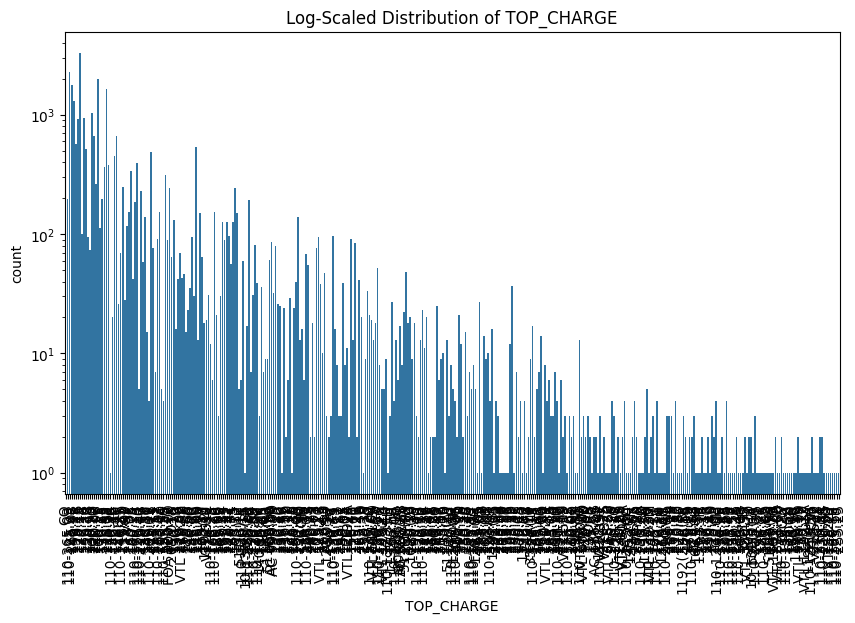

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log scale to the Y-axis (Count)
plt.figure(figsize=(10, 6))
sns.countplot(data=Incarcerated_training, x='TOP_CHARGE')
plt.yscale('log') # This is the magic line
plt.xticks(rotation=90)
plt.title("Log-Scaled Distribution of TOP_CHARGE")
plt.show()

#Pipeline C

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier


Incarcerated_C = Incarcerated_training.dropna(subset=['TOP_CHARGE'])

drop_cols = ['SEALED','DISCHARGED_DT','INMATEID','ADMITTED_DT']
X_c = Incarcerated_C.drop(columns=['TOP_CHARGE']).copy()
X_c = X_c.drop(columns=drop_cols, errors='ignore')

y_c = Incarcerated_C['TOP_CHARGE'].astype(str)


numeric_features = ['AGE']
categorical_features = ['RACE','INMATE_STATUS_CODE','YEAR','BRADH', 'SRG_FLG','INFRACTION','GENDER']
ordinal_features = ['CUSTODY_LEVEL']

#make pipelines
num_pipeline= make_pipeline(SimpleImputer(strategy= 'median'), StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy='constant', fill_value='unknown'),
                             OneHotEncoder(sparse_output=False))
ord_pipeline = make_pipeline( OrdinalEncoder(categories=[['MIN','MED','MAX']],
                                             handle_unknown='use_encoded_value', unknown_value=-1))



preprocessing = ColumnTransformer([
    ('num',num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
    ('ord',ord_pipeline, ordinal_features),

])

full_pipelineC = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Fit pipeline
full_pipelineC.fit(X_c, y_c)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['RACE', 'INMATE_STATUS_CODE',
                                                   'YEAR', 'BRADH', 'SRG_FLG',
                                                   'INFRACTION', 'GENDER']),
                                                 ('ord',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['MIN',
                                                                                               'MED',
                                                                                               'MAX']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['CUSTODY_LEVEL'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

#Performance metrics

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(full_pipelineC, X_c,y_c, cv=4, scoring ='accuracy')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(


array([0.04660035, 0.04742437, 0.04715181, 0.04905969])

In [ ]:
cross_val_score(full_pipelineC, X_c,y_c, cv=4, scoring ='f1_macro')

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(


array([0.00947125, 0.00778743, 0.00658563, 0.00845586])

In [ ]:
processed_sample = full_pipelineC.named_steps['preprocessor'].transform(X_c.head(10))

feature_names = full_pipelineC.named_steps['preprocessor'].get_feature_names_out()
result_df = pd.DataFrame(processed_sample, columns=feature_names)
result_df.head(10)

,num__AGE,cat__RACE_A,cat__RACE_B,cat__RACE_I,cat__RACE_O,cat__RACE_U,cat__RACE_W,cat__RACE_unknown,cat__INMATE_STATUS_CODE_CS,cat__INMATE_STATUS_CODE_CSP,...,cat__BRADH_N,cat__BRADH_Y,cat__SRG_FLG_N,cat__SRG_FLG_Y,cat__INFRACTION_N,cat__INFRACTION_Y,cat__GENDER_F,cat__GENDER_M,cat__GENDER_unknown,ord__CUSTODY_LEVEL
0,0.717798,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.292084,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0
2,-1.240487,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0
3,-0.899916,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,0.206941,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
5,1.654370,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
6,1.994941,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7,-0.729630,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2.0
8,-0.644487,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
9,-0.985059,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0
